In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
# import mpscr_models as mpscr
import mpscr_models_custom_base as mpscr
import pwexp
import gndr_utils as utils
import mps

E0000 00:00:1784574477.546213   47596 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784574477.551249   47596 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784574477.564241   47596 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784574477.564272   47596 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784574477.564275   47596 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784574477.564278   47596 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1784574480.329316   47596 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4265 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784574480.368060   47596 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4265 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784574480.407393   47596 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4265 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784574480.408560   47596 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4265 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784574480.410443   47596 gpu_device.cc:2019] Cr

# Load data

In [2]:
df = pd.read_csv("OASIS Data/patients_full_data.csv")
print("Data dimensions: {}".format(df.shape))
df.head(3)

Data dimensions: (737, 277)


,oasis_id,time_days,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,cdr,...,vol_wm_rh_superiorfrontal,vol_wm_rh_superiorparietal,vol_wm_rh_superiortemporal,vol_wm_rh_supramarginal,vol_wm_rh_frontalpole,vol_wm_rh_temporalpole,vol_wm_rh_transversetemporal,vol_wm_rh_insula,vol_left_unsegmented_white_matter,vol_right_unsegmented_white_matter
0,OAS30001,5055,0,65.1945,NaN,2,23.0,5184,79.40,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OAS30002,2590,0,67.2521,76.9397,1,34.0,2961,75.36,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OAS30003,5093,0,58.8137,NaN,2,33.0,5651,74.30,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


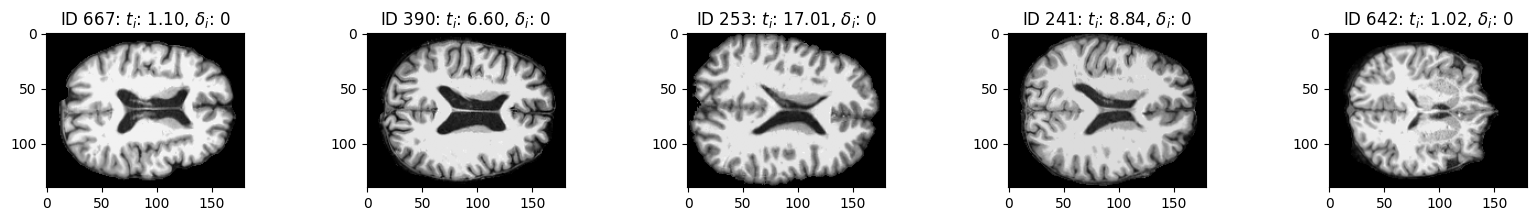

In [3]:
x = np.load("OASIS Data/patients_images.npy")
x = np.expand_dims(x, axis=-1)

np.random.seed(12)

random_idx = np.random.choice(np.arange(x.shape[0]), size = 5)

fig, ax = plt.subplots(nrows = 1, ncols = 5, figsize = (20,2))

for i, a in enumerate(ax):
    idx = random_idx[i]
    a.imshow(x[idx,:,:,0], cmap = "gray")
    a.set_title(r"ID {}: $t_i$: {:.2f}, $\delta_i$: {}".format(idx, df.loc[idx, "time_days"] / 365, df.loc[idx, "delta"]))

In [4]:
from sklearn.model_selection import train_test_split

indices = np.arange(df.shape[0])
idx_train, idx_test = train_test_split(indices, train_size = 0.7, random_state = 42)

print("Train dimension: {}".format(idx_train.shape))
print("Test dimension: {}".format(idx_test.shape))

y_train = df.loc[idx_train, "time_days"] / 365
y_test = df.loc[idx_test, "time_days"] / 365
delta_train = df.loc[idx_train, "delta"]
delta_test = df.loc[idx_test, "delta"]

x_train = x[idx_train]
x_test = x[idx_test]

Train dimension: (515,)
Test dimension: (222,)


# Neural network architecture

In [5]:
def neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    
    model.convolution1 = keras.layers.Conv2D(filters = 4, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                            kernel_initializer = initializer, dtype = tf.float32)
    model.pooling1 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
    model.convolution2 = keras.layers.Conv2D(filters = 24, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                            kernel_initializer = initializer, dtype = tf.float32)
    model.pooling2 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
    model.convolution3 = keras.layers.Conv2D(filters = 32, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                            kernel_initializer = initializer, dtype = tf.float32)
    model.pooling3 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
    model.flatten = keras.layers.Reshape(target_shape=(-1,))
    model.dense1 = keras.layers.Dense(units = 128, activation = tf.nn.tanh, kernel_initializer = initializer, dtype = tf.float32)
    model.dense2 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = False)
    
def neural_network_call(model, x_input, training = False):
    x = model.convolution1(x_input)
    x = model.pooling1(x)
    x = model.convolution2(x)
    x = model.pooling2(x)
    x = model.convolution3(x)
    x = model.pooling3(x)
    x = model.flatten(x)
    x = model.dense1(x)
    x = model.dense2(x)
    return x

def neural_network_call_nolast(model, x_input):
    x = model.convolution1(x_input)
    x = model.pooling1(x)
    x = model.convolution2(x)
    x = model.pooling2(x)
    x = model.convolution3(x)
    x = model.pooling3(x)
    x = model.flatten(x)
    x = model.dense1(x)
    return x

First, we will consider the standard promotion time cure model proposed by Xie & Yu (2021). For that, we consider the Poisson distribution for the number of latent causes. Below is the code to consider that model and train it.

### Piecewise-exponential base

In [6]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

poisson_spec = mpscr.MPSPoisson()
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = 5)

with tf.device("/GPU:0"):
    poisson_model = mpscr.build_mpscr_model(y_train, delta_train, x_train.shape[1:], poisson_spec, pwexp_spec,
                                            neural_network = neural_network, neural_network_call = neural_network_call,
                                            neural_network_call_nolast = neural_network_call_nolast,
                                            seed = 10)
    poisson_model.train_model(epochs = 5000, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = False,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
    
    poisson_results = poisson_model.get_survival_cure(y_train, x_train, y_test, x_test, ngrid = 100)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...


I0000 00:00:1784574492.125910   47683 cuda_dnn.cc:529] Loaded cuDNN version 92400


Optimizing... Epoch: [ 223 / 5000 ]  | Avg. Train NLL:  0.268141359 | Avg. Validation NLL:  0.477943599 | Best Avg. Validation NLL:  0.464092404 | Speed:  0.215719849  epoch/s    | Elapsed Time:  48.105526  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 834 / 5000 ]  | Avg. Train NLL:  0.197495744 | Best Avg. Train NLL:  0.197495744 | Avg. Validation NLL:  0.591178536 | Speed:  0.0960078463  epoch/s    | Elapsed Time:  80.0705414  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 138.334 seconds.


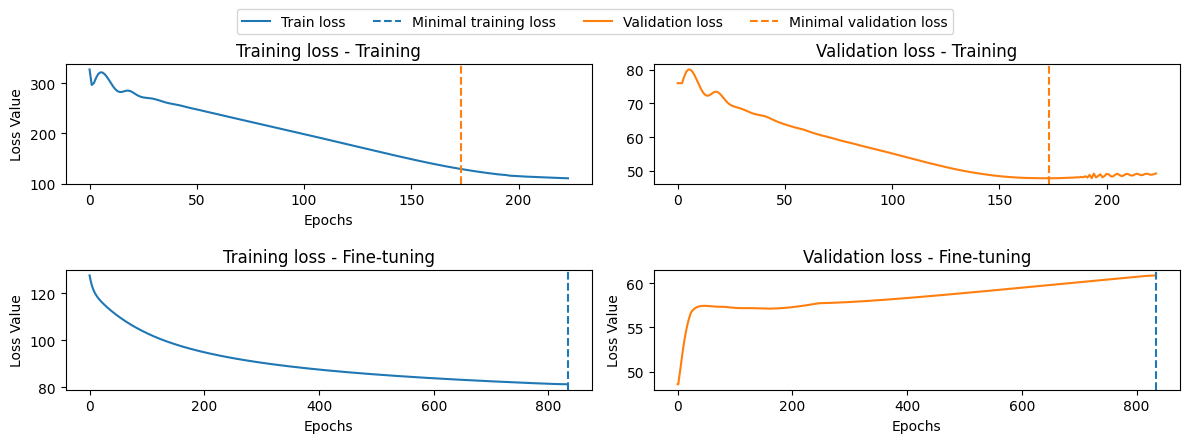

In [7]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,4))

utils.plot_model_convergence( poisson_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

It seems that the neural network was not able to properly learn the convolutional features of the data.

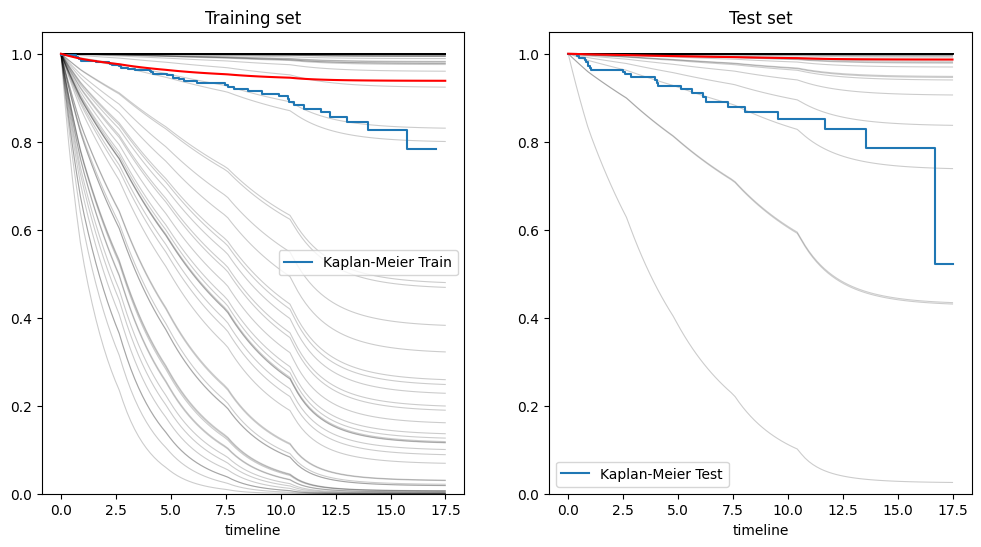

In [8]:
utils.average_kaplan_meier_train_test(poisson_results["ts_grid"],
                                      poisson_results["S_ts_train"], poisson_results["S_ts_test"],
                                      y_train, delta_train, y_test, delta_test, show_individual = True)

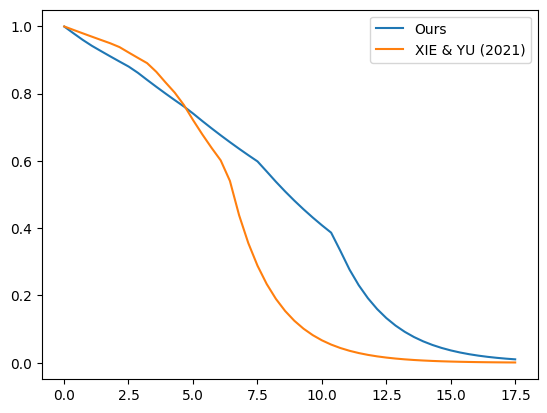

In [9]:
s = pwexp_spec.s
alpha_pred = poisson_model.predict("alpha")

t = np.linspace(0.01, np.max(np.concatenate([y_train, y_test])))
S_t_base = pwexp.cdf(t, alpha_pred, s, lower_tail = False)

plt.plot(t, S_t_base, label = "Ours")

s_xie = np.array([0, 2.062, 3.36, 4.495, 6.32, 12.2])
alpha_xie = np.array([0.02872308, 0.04870019, 0.10390695, 0.16946955, 0.5868493, 0.5868493])

S_t_base_xie = pwexp.cdf(t, alpha_xie, s_xie, lower_tail = False)

plt.plot(t, S_t_base_xie, label = "XIE & YU (2021)")
plt.legend()

plt.show()

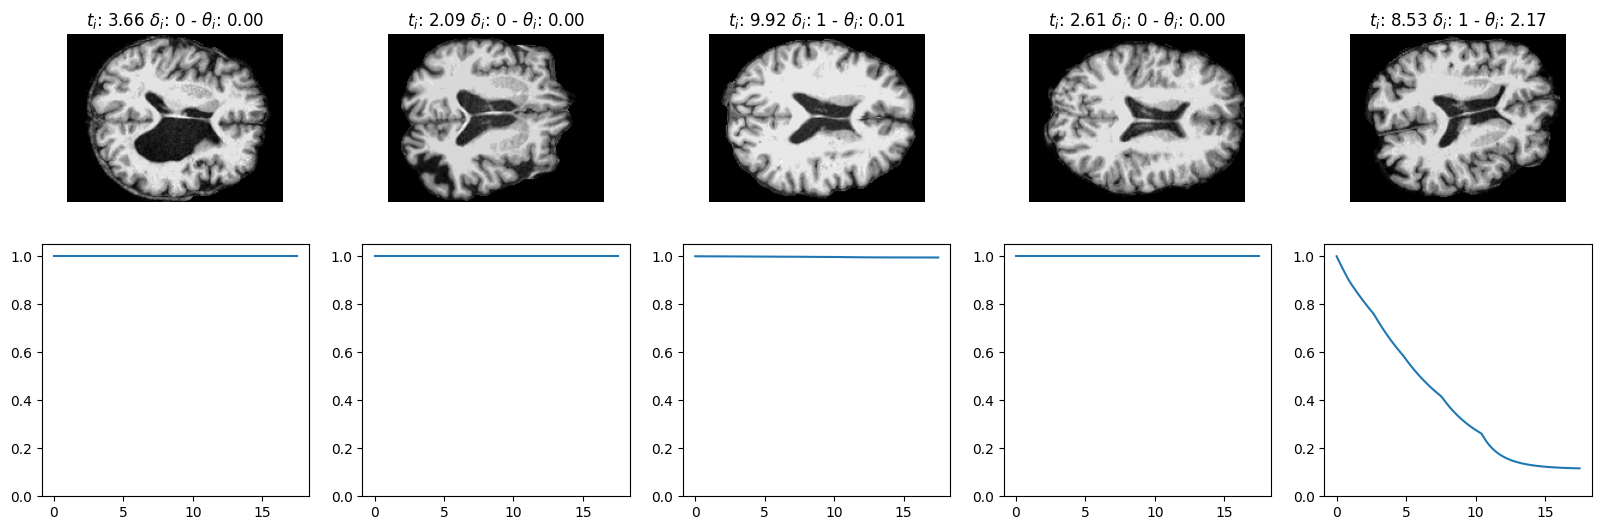

In [10]:
np.random.seed(10)

idx = np.random.choice(np.arange(x_train.shape[0]), size = 5)

fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize = (20,6),
                       gridspec_kw = {
                           'height_ratios': [1,1.5],
                           'width_ratios': [1,1,1,1,1]
                       })

t = np.linspace(0.01, np.max(y_train))

for i in range(5):
    ax[0,i].imshow( x_train[idx[i]], cmap = "gray" )
    ax[0,i].set_title(r"$t_i$: {:.2f} $\delta_i$: {} - $\theta_i$: {:.2f}".format(y_train.iloc[idx[i]], delta_train.iloc[idx[i]], poisson_results["theta_train"].numpy()[idx[i]]))
    ax[0,i].set_axis_off()

    ax[1,i].plot( poisson_results["ts_grid"].flatten(), poisson_results["S_ts_train"].numpy()[:, idx[i]] )
    ax[1,i].set_ylim(0, 1.05)

As we can see, from the five sampled patients above, the model was able to correctly identify one of which indeed experienced the event 8 and a half years later than their respective brain image. The other uncured patient above (that we know of) was associated with a higher cure. Possibly, if the model is confirmed to indeed capture patterns of Alzheimer's Disease (AD), that lack of detection may indicate that the brain decay took place years after the first brain image.

To confirm that the model is able to satisfactorily predict the time to AD diagnostic, we plot the average Kaplan-Meier and predictive survival curves for both groups of censored and uncensored patients. Surely, the KM curve for the censored group will simply be a constant function at 1. We must compare that exact behaviour both in train and test sets to ensure the above property is not simply due to model overfitting.

Text(0.5, 1.0, 'Train set uncensored')

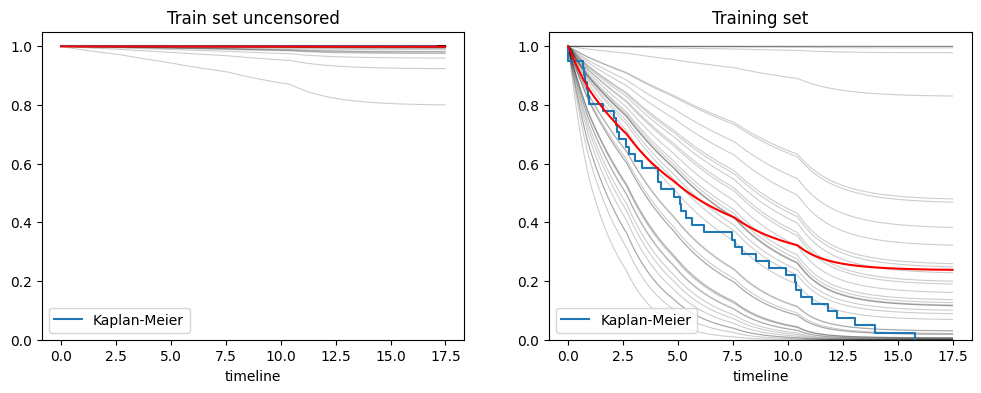

In [11]:
ts_grid = poisson_results["ts_grid"]

S_ts_train = poisson_results["S_ts_train"].numpy()
S_ts_train_censored = S_ts_train[:, delta_train == 0]
S_ts_train_uncensored = S_ts_train[:, delta_train == 1]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_censored,
                           y_train[delta_train == 0], delta_train[delta_train == 0], show_individual = True, ax = ax[0])
ax[0].set_title("Train set censored")

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_uncensored,
                           y_train[delta_train == 1], delta_train[delta_train == 1], show_individual = True, ax = ax[1])
ax[0].set_title("Train set uncensored")

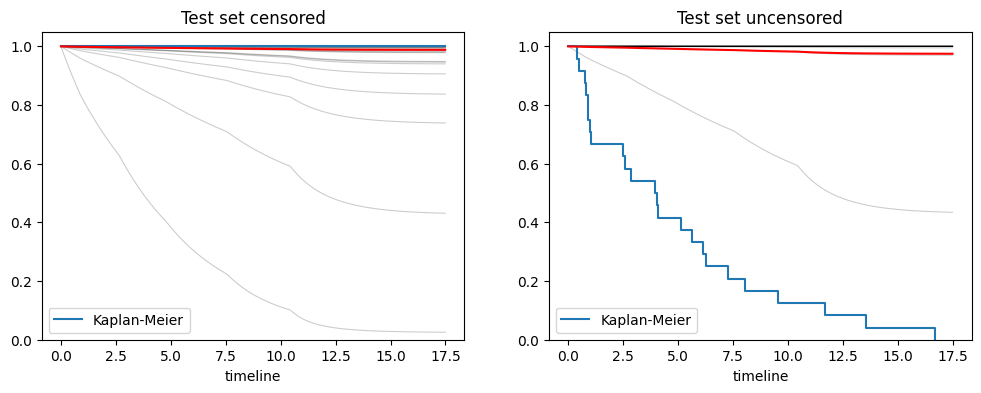

In [12]:
ts_grid = poisson_results["ts_grid"]

S_ts_test = poisson_results["S_ts_test"].numpy()
S_ts_test_censored = S_ts_test[:, delta_test == 0]
S_ts_test_uncensored = S_ts_test[:, delta_test == 1]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier(ts_grid,
                           S_ts_test_censored,
                           y_test[delta_test == 0], delta_test[delta_test == 0], show_individual = True, ax = ax[0])
ax[0].set_title("Test set censored")

utils.average_kaplan_meier(ts_grid,
                           S_ts_test_uncensored,
                           y_test[delta_test == 1], delta_test[delta_test == 1], show_individual = True, ax = ax[1])
ax[1].set_title("Test set uncensored")

plt.show()

The plots above confirm an exact model overfitting. While in the training set the model attributes higher survival curves for those censored patients, suggesting it indeed identified signs of cure in their brain images, also giving much heavier survival curves for those that actually experienced the event, when checking the test set, the model greatly overestimates the survival curves over the test set.

That can only indicate that the model is learning very specific patterns in the images in the train set, which are not present in the test images and surely do not correlate with the time to AD diagnostic. Those results suggest a need of regularizing the model so that train and test sets agree in their predictions.

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Used for resizing the heatmap back to 140x180

def generate_gradcam(model, image_array):
    """
    Generates a Grad-CAM heatmap for the custom MPSCR survival network.
    Expected image_array shape: (1, 140, 180, 1)
    """
    img_tensor = tf.convert_to_tensor(image_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        # 1. Forward pass up to your last convolutional layer
        x = model.convolution1(img_tensor)
        x = model.pooling1(x)
        x = model.convolution2(x)
        x = model.pooling2(x)
        
        # This is the layer we want to visualize
        last_conv_output = model.convolution3(x)
        
        # Tell the tape to track this specific tensor
        tape.watch(last_conv_output)

        # 2. Complete the rest of the forward pass
        x = model.pooling3(last_conv_output)
        
        # Handle whether you are currently using Flatten or GAP
        x = model.flatten(x)
        x = model.dense1(x)
        predictions = model.dense2(x)
        
        target_score = predictions[0, 0]

    # 3. Calculate the gradients of the output score with respect to the feature maps
    grads = tape.gradient(target_score, last_conv_output)

    # 4. Global Average Pooling of the gradients to get the "weight" of each feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply the feature maps by their gradient weights
    last_conv_output = last_conv_output[0] # Drop the batch dimension
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Apply ReLU (we only care about pixels that had a *positive* influence on the prediction)
    heatmap = tf.nn.relu(heatmap)

    # 7. Normalize the heatmap to be between 0 and 1
    heatmap_max = tf.math.reduce_max(heatmap)
    if heatmap_max != 0:
        heatmap = heatmap / heatmap_max
        
    return heatmap.numpy()

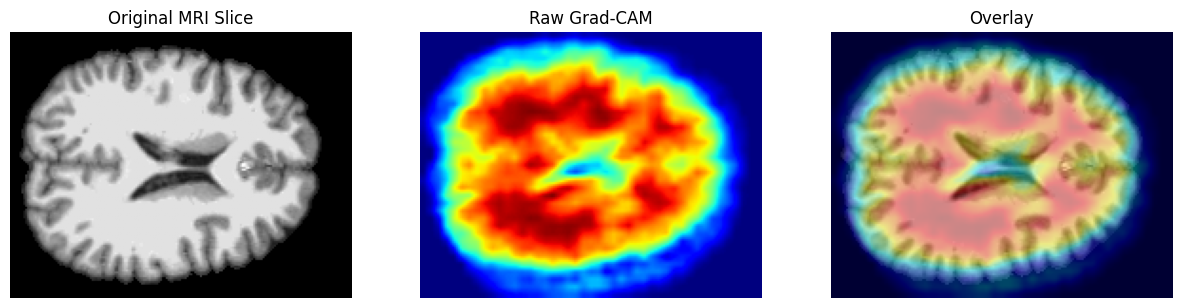

In [20]:
def plot_gradcam(model, image_array):
    """
    Overlays the Grad-CAM heatmap onto the original MRI slice.
    """
    # 1. Get the heatmap
    heatmap = generate_gradcam(model, image_array)
    
    # 2. Extract the original 2D image (dropping batch and channel dims)
    original_image = image_array[0, :, :, 0]
    
    # 3. Resize heatmap to match the original image size (180, 140) -> OpenCV format (width, height)
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    
    # 4. Convert heatmap to RGB format for visualization
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # 5. Convert original image to RGB
    original_img_norm = np.uint8(255 * (original_image / np.max(original_image)))
    original_colored = cv2.cvtColor(original_img_norm, cv2.COLOR_GRAY2RGB)
    
    # 6. Blend them together (0.6 opacity for MRI, 0.4 for heatmap)
    superimposed_img = cv2.addWeighted(original_colored, 0.6, heatmap_colored, 0.4, 0)
    
    # Plotting
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title("Original MRI Slice")
    ax[0].axis('off')
    
    ax[1].imshow(heatmap_resized, cmap='jet')
    ax[1].set_title("Raw Grad-CAM")
    ax[1].axis('off')
    
    ax[2].imshow(superimposed_img)
    ax[2].set_title("Overlay")
    ax[2].axis('off')
    
    plt.show()

# --- HOW TO RUN IT ---
# Grab the very first patient in your dataset, ensure shape is (1, 140, 180, 1)
sample_patient = x_train[0:1] 
plot_gradcam(poisson_model, sample_patient)

### Weibull base

In [13]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

poisson_spec = mpscr.MPSPoisson()
weibull_spec = mpscr.BaseWeibull()

with tf.device("/GPU:0"):
    poisson_weibull_model = mpscr.build_mpscr_model(y_train, delta_train, x_train.shape[1:], poisson_spec, weibull_spec,
                                                    neural_network = neural_network, neural_network_call = neural_network_call,
                                                    neural_network_call_nolast = neural_network_call_nolast,
                                                    seed = 10)
    poisson_weibull_model.train_model(epochs = 5000, x = x_train, data = data_train,
                                      shuffle = True,
                                      get_covariances = False,
                                      validation = True, val_prop = 0.2, force_training_validation = False,
                                      optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                      optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                                      fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                      early_stopping = True, early_stopping_patience = 50,
                                      early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                                      reduce_lr = True, reduce_lr_warmup = 0,
                                      reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                                      reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                      fine_tune = True,
                                      finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                                      finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                                      finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                      finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                                      finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                      deterministic = True,
                                      verbose = True, print_freq = 1)
    poisson_weibull_results = poisson_weibull_model.get_survival_cure(y_train, x_train, y_test, x_test, ngrid = 100)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 203 / 5000 ]  | Avg. Train NLL:  0.316781282 | Avg. Validation NLL:  0.485497206 | Best Avg. Validation NLL:  0.467132151 | Speed:  0.365811974  epoch/s    | Elapsed Time:  74.2598267  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 1579 / 5000 ]  | Avg. Train NLL:  0.230148926 | Best Avg. Train NLL:  0.230148926 | Avg. Validation NLL:  0.521364212 | Speed:  0.0980767608  epoch/s    | Elapsed Time:  154.863205  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 234.766 seconds.


In [14]:
poisson_weibull_model.predict("alpha")

array([1.1970254, 6.758784 ], dtype=float32)

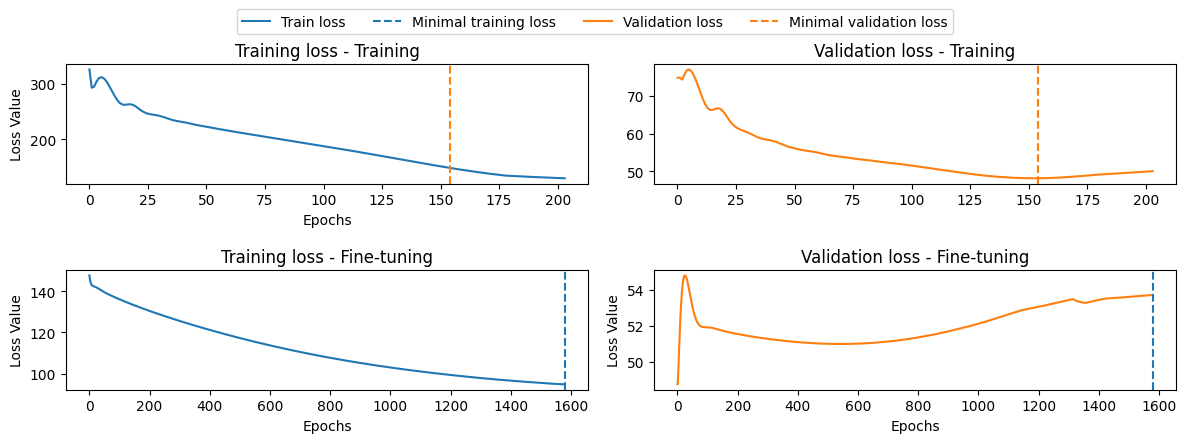

In [15]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,4))

utils.plot_model_convergence( poisson_weibull_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

Text(0.5, 1.0, 'Train set uncensored')

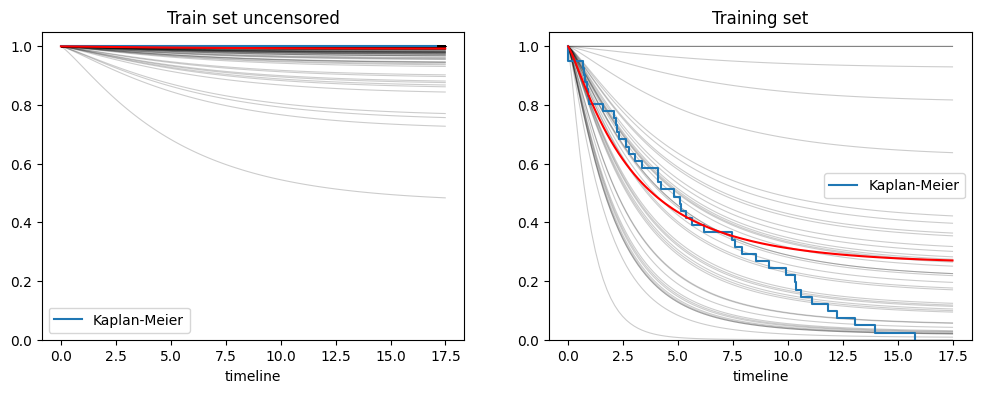

In [16]:
ts_grid = poisson_weibull_results["ts_grid"]

S_ts_train = poisson_weibull_results["S_ts_train"].numpy()
S_ts_train_censored = S_ts_train[:, delta_train == 0]
S_ts_train_uncensored = S_ts_train[:, delta_train == 1]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_censored,
                           y_train[delta_train == 0], delta_train[delta_train == 0], show_individual = True, ax = ax[0])
ax[0].set_title("Train set censored")

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_uncensored,
                           y_train[delta_train == 1], delta_train[delta_train == 1], show_individual = True, ax = ax[1])
ax[0].set_title("Train set uncensored")

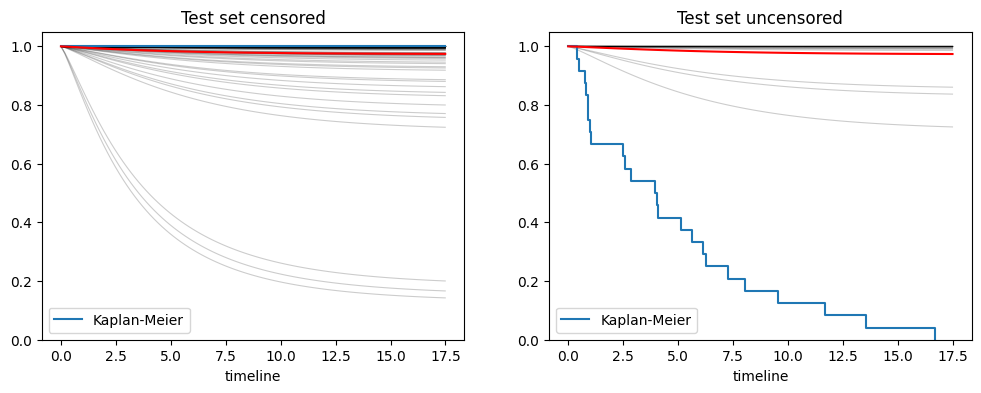

In [17]:
ts_grid = poisson_weibull_results["ts_grid"]

S_ts_test = poisson_weibull_results["S_ts_test"].numpy()
S_ts_test_censored = S_ts_test[:, delta_test == 0]
S_ts_test_uncensored = S_ts_test[:, delta_test == 1]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier(ts_grid,
                           S_ts_test_censored,
                           y_test[delta_test == 0], delta_test[delta_test == 0], show_individual = True, ax = ax[0])
ax[0].set_title("Test set censored")

utils.average_kaplan_meier(ts_grid,
                           S_ts_test_uncensored,
                           y_test[delta_test == 1], delta_test[delta_test == 1], show_individual = True, ax = ax[1])
ax[1].set_title("Test set uncensored")

plt.show()